<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/water_hammer_simulation_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water-hammer simulation with NeqSim

This notebook develops a reproducible method-of-characteristics (MOC) workflow for a
pressurized water pipeline. It preserves the original tutorial's valve-closure,
pressure-history, closure-time, cavitation-screening, inclined-pipe, and material
examples while updating every calculation to the released `WaterHammerPipe` API.

**Intended audience:** process, pipeline, mechanical, and safety engineers; graduate
students; and Python users with basic fluid-mechanics knowledge.

## Prerequisites and learning objectives

You should know the meanings of pressure, velocity, density, pipe diameter, and valve
closure. No local NeqSim checkout or private data is required.

After completing the notebook, you can:

1. create a liquid feed and initialize a `WaterHammerPipe`;
2. select a defensible acoustic wave speed and stable MOC time step;
3. impose a time-dependent downstream-valve closure;
4. retrieve pressure, velocity, time-history, and spatial-envelope results;
5. compare rapid and controlled closures;
6. screen vapor-pressure margin and uphill-line behavior;
7. compare pipe-wall materials with the Korteweg relation; and
8. select an emergency-shutdown closure time against pressure criteria.

## 1. Colab-compatible setup

The setup cell installs the latest public PyPI release only when `neqsim` is absent.
NumPy, pandas, Matplotlib, and IPython are standard Colab dependencies. The following
cell records the actual software versions used for the retained results.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
import importlib.metadata
import math
import platform

from IPython.display import display
import jpype
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import fluid

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_SYSTEM = jpype.JClass("java.lang.System")
JAVA_VERSION = JAVA_SYSTEM.getProperty("java.version")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#5F6368",
    "yellow": "#F0E442",
}

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")
print(f"Java version: {JAVA_VERSION}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java version: 17.0.19


## 2. Engineering context and governing equations

Closing a valve changes liquid velocity and launches pressure waves. For a rapid,
frictionless velocity change, the Joukowsky estimate is

$$
\Delta p = \rho a \Delta v
$$

where $\Delta p$ is surge pressure in Pa, $\rho$ is liquid density in kg/m³, $a$ is wave
speed in m/s, and $\Delta v$ is velocity change in m/s. It is a useful upper-bound check,
not a complete transient solution.

The elastic-wall Korteweg relation used here is

$$
a = \frac{c}{\sqrt{1 + K D/(E e)}}
$$

where $c$ is the unconfined liquid sound speed, $K=\rho c^2$ is bulk modulus, $D$ is
internal diameter, $E$ is pipe Young's modulus, and $e$ is wall thickness.

`WaterHammerPipe` solves the one-dimensional liquid equations with a method of
characteristics. A useful closure-time scale and the Courant stability limit are

$$
t_{\mathrm{critical}} = \frac{2L}{a}
$$

$$
\Delta t \leq C_{\mathrm{n}}\frac{\Delta x}{a}
$$

Here $L$ is pipe length in m, $\Delta x$ is node spacing in m, $\Delta t$ is time step in
s, and $C_{\mathrm{n}}$ is the Courant number. Closures much faster than
$t_{\mathrm{critical}}$ approach the rapid-closure surge.

## 3. Design basis, assumptions, and validity limits

The base case represents a 1 km carbon-steel water line:

- inlet: 40 bara and 25 °C;
- mass flow: 140 kg/s;
- internal diameter: 0.300 m;
- wall thickness: 0.010 m;
- absolute roughness: 46 µm;
- 51 equally spaced MOC nodes;
- constant upstream reservoir pressure;
- one downstream valve;
- single-phase, isothermal liquid with constant properties.

The water sound speed is set to 1482 m/s at 25 °C as an engineering reference. NeqSim
supplies the liquid state, density, viscosity, stream, and transient equipment model.
The Korteweg-corrected speed is passed explicitly because cubic equations of state are not
precision liquid-acoustics models. Pipe restraint, viscoelasticity, unsteady friction, air
pockets, vapor cavities, and fluid-structure interaction are outside this tutorial.

In [3]:
PIPE_LENGTH_M = 1000.0
PIPE_DIAMETER_M = 0.300
WALL_THICKNESS_M = 0.010
ROUGHNESS_M = 46.0e-6
NUMBER_OF_NODES = 51
STEEL_MODULUS_PA = 210.0e9

INLET_PRESSURE_BARA = 40.0
INLET_TEMPERATURE_C = 25.0
MASS_FLOW_KG_S = 140.0

WATER_DENSITY_REFERENCE_KG_M3 = 997.0
WATER_SOUND_SPEED_REFERENCE_M_S = 1482.0
WATER_VAPOR_PRESSURE_BARA = 0.0317

### How NeqSim represents this workflow

`fluid("srk")` creates the thermodynamic system and the Java `Stream` carries its
pressure, temperature, composition, and mass flow. `WaterHammerPipe` clones the inlet
state, initializes density and viscosity, calculates steady friction, and then advances
the pressure head and volumetric flow on the spatial grid.

The thermodynamic model is adequate for density and viscosity in this educational water
case. The independent acoustic reference prevents the cubic-EOS liquid sound speed from
becoming an unexplained model assumption.

In [4]:
def create_water_feed(
    pressure_bara,
    mass_flow_kg_s=MASS_FLOW_KG_S,
):
    water = fluid("srk")
    water.addComponent("water", 1.0)
    water.setMixingRule("classic")
    water.setTemperature(INLET_TEMPERATURE_C, "C")
    water.setPressure(pressure_bara, "bara")

    stream_class = jneqsim.process.equipment.stream.Stream
    feed = stream_class("pressurized water feed", water)
    feed.setFlowRate(mass_flow_kg_s, "kg/sec")
    feed.setTemperature(INLET_TEMPERATURE_C, "C")
    feed.setPressure(pressure_bara, "bara")
    feed.run()
    return feed

In [5]:
base_feed = create_water_feed(INLET_PRESSURE_BARA)
base_system = base_feed.getThermoSystem()
base_system.initPhysicalProperties()

neqsim_density_kg_m3 = float(base_system.getDensity("kg/m3"))
neqsim_viscosity_pa_s = float(base_system.getViscosity("kg/msec"))
neqsim_sound_speed_m_s = float(base_system.getPhase(0).getSoundSpeed())

fluid_report = pd.DataFrame(
    {
        "quantity": [
            "Pressure",
            "Temperature",
            "Density",
            "Dynamic viscosity",
            "EOS phase sound speed",
        ],
        "value": [
            base_feed.getPressure("bara"),
            base_feed.getTemperature("C"),
            neqsim_density_kg_m3,
            neqsim_viscosity_pa_s,
            neqsim_sound_speed_m_s,
        ],
        "unit": ["bara", "°C", "kg/m³", "Pa·s", "m/s"],
    }
)
display(fluid_report)

,quantity,value,unit
0,Pressure,40.000000,bara
1,Temperature,25.000000,°C
2,Density,1002.498503,kg/m³
3,Dynamic viscosity,0.000895,Pa·s
4,EOS phase sound speed,3476.270174,m/s


The EOS phase sound speed is reported transparently but is not used as an experimental
water-acoustic benchmark. The next calculation applies the Korteweg elastic-wall
correction to the documented 25 °C water reference.

In [6]:
def korteweg_wave_speed(
    elastic_modulus_pa,
    diameter_m=PIPE_DIAMETER_M,
    wall_thickness_m=WALL_THICKNESS_M,
):
    bulk_modulus_pa = (
        WATER_DENSITY_REFERENCE_KG_M3
        * WATER_SOUND_SPEED_REFERENCE_M_S
        * WATER_SOUND_SPEED_REFERENCE_M_S
    )
    compliance_multiplier = (
        1.0
        + bulk_modulus_pa
        * diameter_m
        / (elastic_modulus_pa * wall_thickness_m)
    )
    return WATER_SOUND_SPEED_REFERENCE_M_S / math.sqrt(
        compliance_multiplier
    )


STEEL_WAVE_SPEED_M_S = korteweg_wave_speed(STEEL_MODULUS_PA)
CRITICAL_CLOSURE_TIME_S = (
    2.0 * PIPE_LENGTH_M / STEEL_WAVE_SPEED_M_S
)

print(f"Steel-pipe wave speed: {STEEL_WAVE_SPEED_M_S:.3f} m/s")
print(
    "Critical closure time: "
    f"{CRITICAL_CLOSURE_TIME_S:.3f} s"
)

Steel-pipe wave speed: 1293.438 m/s
Critical closure time: 1.546 s


## 4. Configure and initialize `WaterHammerPipe`

The helper creates a fresh stream and pipe for every scenario. This prevents hidden state
from one transient affecting another. `run()` establishes the initial steady profile;
`runTransient(dt)` then advances one time step. The downstream `VALVE` boundary is varied
explicitly by the caller.

In [7]:
def build_water_hammer_pipe(
    inlet_pressure_bara=INLET_PRESSURE_BARA,
    mass_flow_kg_s=MASS_FLOW_KG_S,
    elevation_change_m=0.0,
    elastic_modulus_pa=STEEL_MODULUS_PA,
    wave_speed_m_s=None,
):
    feed = create_water_feed(
        inlet_pressure_bara,
        mass_flow_kg_s,
    )
    pipe_class = jneqsim.process.equipment.pipeline.WaterHammerPipe
    pipe = pipe_class("water-hammer line", feed)
    pipe.setLength(PIPE_LENGTH_M)
    pipe.setDiameter(PIPE_DIAMETER_M)
    pipe.setWallThickness(WALL_THICKNESS_M)
    pipe.setRoughness(ROUGHNESS_M)
    pipe.setNumberOfNodes(NUMBER_OF_NODES)
    pipe.setPipeElasticModulus(elastic_modulus_pa)
    pipe.setElevationChange(elevation_change_m)
    pipe.setUpstreamBoundary("RESERVOIR")
    pipe.setDownstreamBoundary("VALVE")
    pipe.setCourantNumber(1.0)

    if wave_speed_m_s is None:
        wave_speed_m_s = korteweg_wave_speed(
            elastic_modulus_pa,
        )

    pipe.setWaveSpeed(wave_speed_m_s)
    pipe.run()
    return pipe

In [8]:
steady_pipe = build_water_hammer_pipe()
positions_m = np.linspace(
    0.0,
    PIPE_LENGTH_M,
    NUMBER_OF_NODES,
)
initial_pressure_bar = np.asarray(
    steady_pipe.getPressureProfile("bar"),
    dtype=float,
)
initial_velocity_m_s = np.asarray(
    steady_pipe.getVelocityProfile(),
    dtype=float,
)
node_spacing_m = PIPE_LENGTH_M / (NUMBER_OF_NODES - 1)
stable_time_step_s = float(steady_pipe.getMaxStableTimeStep())
courant_number = (
    STEEL_WAVE_SPEED_M_S
    * stable_time_step_s
    / node_spacing_m
)

steady_report = pd.DataFrame(
    {
        "quantity": [
            "Mean initial velocity",
            "Initial pressure drop",
            "Node spacing",
            "Maximum stable time step",
            "Computed Courant number",
        ],
        "value": [
            initial_velocity_m_s.mean(),
            initial_pressure_bar[0] - initial_pressure_bar[-1],
            node_spacing_m,
            stable_time_step_s,
            courant_number,
        ],
        "unit": ["m/s", "bar", "m", "s", "–"],
    }
)
display(steady_report)

,quantity,value,unit
0,Mean initial velocity,1.975659,m/s
1,Initial pressure drop,0.943483,bar
2,Node spacing,20.000000,m
3,Maximum stable time step,0.015463,s
4,Computed Courant number,1.000000,–


The flow rate determines initial velocity; the released class has no
`setInitialVelocity` method. Likewise, valve closure is a schedule of
`setValveOpening` calls rather than one unsupported closure-time setter.

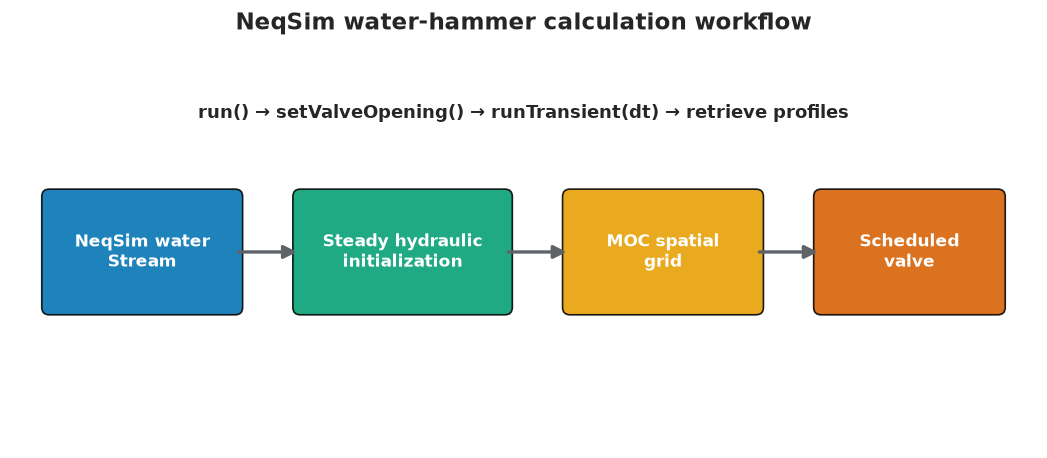

In [9]:
fig, ax = plt.subplots(figsize=(11.0, 4.4))
ax.set_xlim(0.0, 11.0)
ax.set_ylim(0.0, 4.4)
ax.axis("off")

boxes = [
    (0.4, 1.5, 2.0, 1.2, "NeqSim water\nStream", COLORS["blue"]),
    (3.1, 1.5, 2.2, 1.2, "Steady hydraulic\ninitialization", COLORS["green"]),
    (6.0, 1.5, 2.0, 1.2, "MOC spatial\ngrid", COLORS["orange"]),
    (8.7, 1.5, 1.9, 1.2, "Scheduled\nvalve", COLORS["red"]),
]

for x_pos, y_pos, width, height, label, color in boxes:
    patch = FancyBboxPatch(
        (x_pos, y_pos),
        width,
        height,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.88,
    )
    ax.add_patch(patch)
    ax.text(
        x_pos + width / 2.0,
        y_pos + height / 2.0,
        label,
        color="white",
        ha="center",
        va="center",
        weight="bold",
    )

for start_x, end_x in ((2.4, 3.1), (5.3, 6.0), (8.0, 8.7)):
    arrow = FancyArrowPatch(
        (start_x, 2.1),
        (end_x, 2.1),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=2.0,
        color=COLORS["grey"],
    )
    ax.add_patch(arrow)

ax.text(
    5.5,
    3.55,
    "run() → setValveOpening() → runTransient(dt) → retrieve profiles",
    ha="center",
    fontsize=11,
    weight="bold",
)
ax.set_title(
    "NeqSim water-hammer calculation workflow",
    fontsize=14,
    weight="bold",
)
plt.show()

**Figure interpretation.** The thermodynamic stream supplies the hydraulic initial state.
The pipe then owns the transient grid, boundary conditions, histories, and envelopes.
Rebuilding this chain for each scenario makes sensitivity results reproducible.

## 5. Example 1 — rapid downstream-valve closure

The valve begins closing at 0.20 s and reaches zero opening after the specified duration.
A 0.10 s base closure is much faster than the approximately 1.55 s critical time. The
helper retains native time histories and selected spatial snapshots while using the exact
Courant-limited time step returned by NeqSim.

In [10]:
def simulate_valve_closure(
    inlet_pressure_bara=INLET_PRESSURE_BARA,
    mass_flow_kg_s=MASS_FLOW_KG_S,
    closure_duration_s=0.10,
    total_time_s=4.0,
    closure_start_s=0.20,
    elevation_change_m=0.0,
    elastic_modulus_pa=STEEL_MODULUS_PA,
    snapshot_times_s=(0.25, 0.60, 1.20, 2.00, 3.20),
):
    wave_speed_m_s = korteweg_wave_speed(elastic_modulus_pa)
    pipe = build_water_hammer_pipe(
        inlet_pressure_bara=inlet_pressure_bara,
        mass_flow_kg_s=mass_flow_kg_s,
        elevation_change_m=elevation_change_m,
        elastic_modulus_pa=elastic_modulus_pa,
        wave_speed_m_s=wave_speed_m_s,
    )
    time_step_s = float(pipe.getMaxStableTimeStep())
    initial_pressure = np.asarray(
        pipe.getPressureProfile("bar"),
        dtype=float,
    )
    initial_velocity = np.asarray(
        pipe.getVelocityProfile(),
        dtype=float,
    )
    snapshots = []
    snapshot_labels = []
    next_snapshot_index = 0

    while float(pipe.getCurrentTime()) < total_time_s:
        current_time_s = float(pipe.getCurrentTime())
        closure_fraction = (
            current_time_s - closure_start_s
        ) / closure_duration_s
        valve_opening = 1.0 - min(
            max(closure_fraction, 0.0),
            1.0,
        )
        pipe.setValveOpening(valve_opening)
        pipe.runTransient(time_step_s)

        if next_snapshot_index < len(snapshot_times_s):
            snapshot_time_s = snapshot_times_s[next_snapshot_index]

            if float(pipe.getCurrentTime()) >= snapshot_time_s:
                snapshots.append(
                    np.asarray(
                        pipe.getPressureProfile("bar"),
                        dtype=float,
                    )
                )
                snapshot_labels.append(float(pipe.getCurrentTime()))
                next_snapshot_index += 1

    native_time_s = np.asarray(
        list(pipe.getTimeHistory()),
        dtype=float,
    )
    native_outlet_pressure_bar = np.asarray(
        list(pipe.getPressureHistory()),
        dtype=float,
    ) / 1.0e5

    return {
        "pipe": pipe,
        "positions_m": positions_m.copy(),
        "initial_pressure_bar": initial_pressure,
        "initial_velocity_m_s": initial_velocity,
        "time_s": native_time_s,
        "outlet_pressure_bar": native_outlet_pressure_bar,
        "outlet_velocity_m_s": np.asarray(
            pipe.getVelocityProfile(),
            dtype=float,
        ),
        "snapshot_pressure_bar": snapshots,
        "snapshot_time_s": snapshot_labels,
        "max_envelope_bar": np.asarray(
            pipe.getMaxPressureEnvelope("bar"),
            dtype=float,
        ),
        "min_envelope_bar": np.asarray(
            pipe.getMinPressureEnvelope("bar"),
            dtype=float,
        ),
        "max_pressure_bar": float(pipe.getMaxPressure("bar")),
        "min_pressure_bar": float(pipe.getMinPressure("bar")),
        "wave_speed_m_s": wave_speed_m_s,
        "time_step_s": time_step_s,
        "closure_duration_s": closure_duration_s,
    }

In [11]:
rapid_result = simulate_valve_closure(
    closure_duration_s=0.10,
    total_time_s=4.0,
)
rapid_initial_velocity_m_s = float(
    rapid_result["initial_velocity_m_s"].mean()
)
joukowsky_surge_bar = (
    neqsim_density_kg_m3
    * STEEL_WAVE_SPEED_M_S
    * rapid_initial_velocity_m_s
    / 1.0e5
)
joukowsky_peak_bara = INLET_PRESSURE_BARA + joukowsky_surge_bar

rapid_report = pd.DataFrame(
    {
        "quantity": [
            "Initial velocity",
            "Joukowsky surge",
            "Joukowsky peak estimate",
            "NeqSim maximum pressure",
            "NeqSim minimum pressure",
            "Retained time samples",
        ],
        "value": [
            rapid_initial_velocity_m_s,
            joukowsky_surge_bar,
            joukowsky_peak_bara,
            rapid_result["max_pressure_bar"],
            rapid_result["min_pressure_bar"],
            len(rapid_result["time_s"]),
        ],
        "unit": ["m/s", "bar", "bara", "bara", "bara", "samples"],
    }
)
display(rapid_report)

,quantity,value,unit
0,Initial velocity,1.975659,m/s
1,Joukowsky surge,25.617773,bar
2,Joukowsky peak estimate,65.617773,bara
3,NeqSim maximum pressure,65.493204,bara
4,NeqSim minimum pressure,15.340743,bara
5,Retained time samples,259.000000,samples


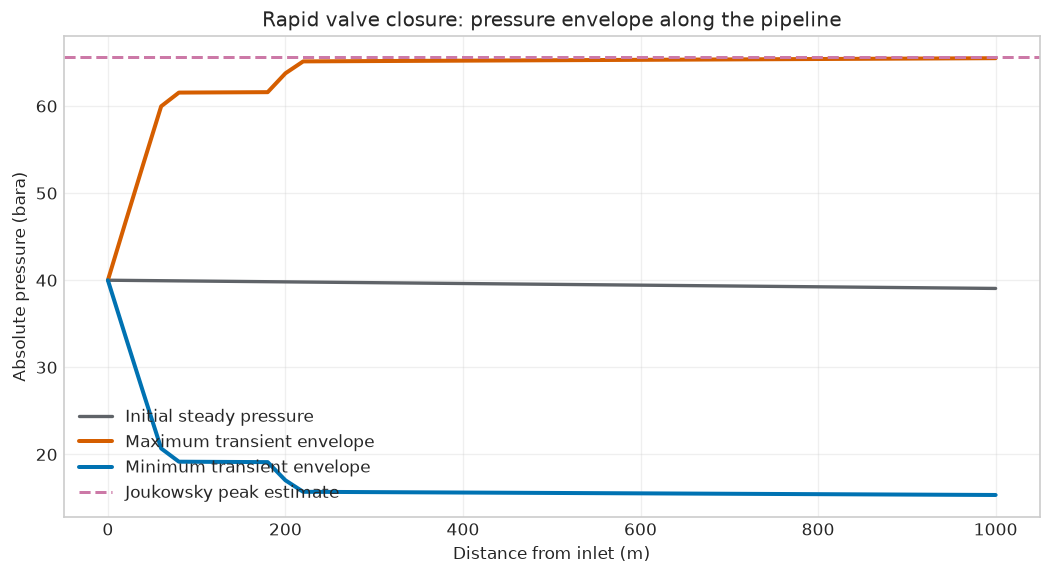

In [12]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.plot(
    positions_m,
    rapid_result["initial_pressure_bar"],
    color=COLORS["grey"],
    linewidth=2.0,
    label="Initial steady pressure",
)
ax.plot(
    positions_m,
    rapid_result["max_envelope_bar"],
    color=COLORS["red"],
    linewidth=2.4,
    label="Maximum transient envelope",
)
ax.plot(
    positions_m,
    rapid_result["min_envelope_bar"],
    color=COLORS["blue"],
    linewidth=2.4,
    label="Minimum transient envelope",
)
ax.axhline(
    joukowsky_peak_bara,
    color=COLORS["purple"],
    linestyle="--",
    linewidth=1.8,
    label="Joukowsky peak estimate",
)
ax.set_xlabel("Distance from inlet (m)")
ax.set_ylabel("Absolute pressure (bara)")
ax.set_title("Rapid valve closure: pressure envelope along the pipeline")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.show()

**Figure interpretation.** The simulated maximum is close to the Joukowsky rapid-closure
estimate, which is the expected limiting behavior. Friction and boundary reflections
create the spatial minimum envelope; the base case remains above vapor pressure.

## 6. Example 2 — pressure and velocity histories

The released API stores the outlet pressure history. Spatial snapshots are collected from
`getPressureProfile("bar")` during integration. This preserves the original time-history
lesson without assuming a nonexistent two-dimensional history accessor.

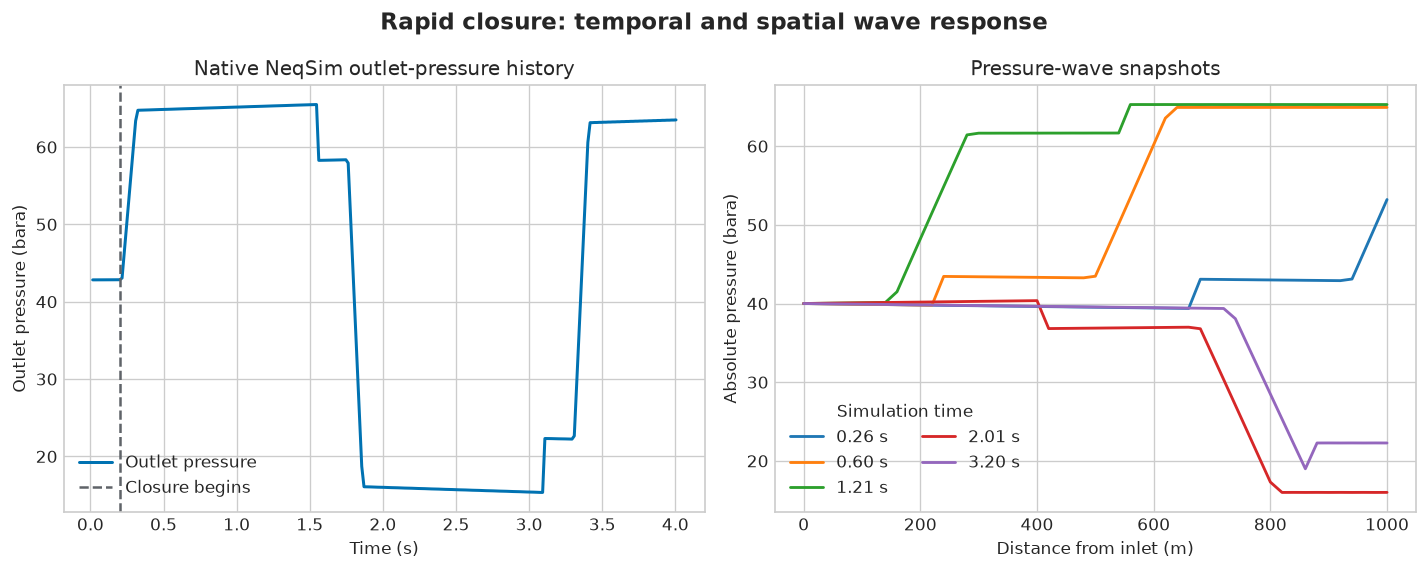

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

axes[0].plot(
    rapid_result["time_s"],
    rapid_result["outlet_pressure_bar"],
    color=COLORS["blue"],
    linewidth=1.8,
    label="Outlet pressure",
)
axes[0].axvline(
    0.20,
    color=COLORS["grey"],
    linestyle="--",
    label="Closure begins",
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Outlet pressure (bara)")
axes[0].set_title("Native NeqSim outlet-pressure history")
axes[0].legend(loc="best")

for snapshot, snapshot_time_s in zip(
    rapid_result["snapshot_pressure_bar"],
    rapid_result["snapshot_time_s"],
):
    axes[1].plot(
        positions_m,
        snapshot,
        linewidth=1.7,
        label=f"{snapshot_time_s:.2f} s",
    )

axes[1].set_xlabel("Distance from inlet (m)")
axes[1].set_ylabel("Absolute pressure (bara)")
axes[1].set_title("Pressure-wave snapshots")
axes[1].legend(title="Simulation time", ncol=2)

fig.suptitle(
    "Rapid closure: temporal and spatial wave response",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Figure interpretation.** The outlet responds first because the closure is applied there.
The wave then travels upstream, reflects at the constant-pressure reservoir, and returns.
The repeating signal is a deterministic wave pattern, not random numerical noise.

## 7. Example 3 — valve-closure-time sensitivity

Closure durations below the critical time produce nearly the same first surge. Once the
closure takes about one round-trip travel time or longer, the reservoir can communicate
with the valve during the event and the peak falls.

In [14]:
closure_durations_s = np.asarray(
    [0.10, 0.50, 1.00, 1.60, 2.40, 3.00],
    dtype=float,
)
closure_results = []

for closure_duration_s in closure_durations_s:
    scenario = simulate_valve_closure(
        closure_duration_s=closure_duration_s,
        total_time_s=5.0,
        snapshot_times_s=(),
    )
    closure_results.append(
        {
            "closure_time_s": closure_duration_s,
            "closure_ratio": (
                closure_duration_s
                / CRITICAL_CLOSURE_TIME_S
            ),
            "maximum_pressure_bara": scenario["max_pressure_bar"],
            "minimum_pressure_bara": scenario["min_pressure_bar"],
        }
    )

closure_table = pd.DataFrame(closure_results)
display(closure_table.round(4))

,closure_time_s,closure_ratio,maximum_pressure_bara,minimum_pressure_bara
0,0.1,0.0647,65.4932,15.3407
1,0.5,0.3234,65.4326,15.3230
2,1.0,0.6467,65.3569,15.2982
3,1.6,1.0348,61.5487,22.4822
4,2.4,1.5521,55.3491,34.4643
5,3.0,1.9402,52.8691,37.9595


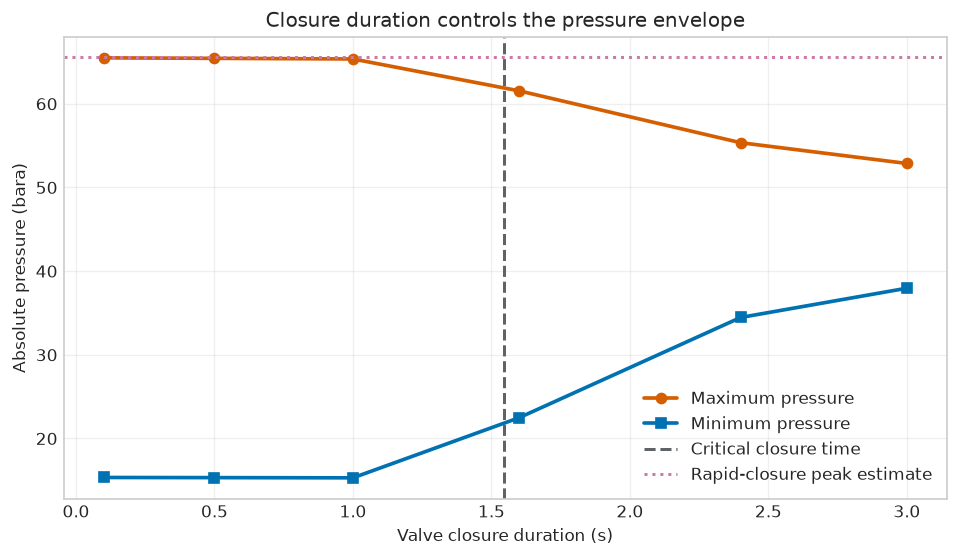

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
ax.plot(
    closure_table["closure_time_s"],
    closure_table["maximum_pressure_bara"],
    marker="o",
    linewidth=2.2,
    color=COLORS["red"],
    label="Maximum pressure",
)
ax.plot(
    closure_table["closure_time_s"],
    closure_table["minimum_pressure_bara"],
    marker="s",
    linewidth=2.2,
    color=COLORS["blue"],
    label="Minimum pressure",
)
ax.axvline(
    CRITICAL_CLOSURE_TIME_S,
    color=COLORS["grey"],
    linestyle="--",
    linewidth=1.8,
    label="Critical closure time",
)
ax.axhline(
    joukowsky_peak_bara,
    color=COLORS["purple"],
    linestyle=":",
    linewidth=1.8,
    label="Rapid-closure peak estimate",
)
ax.set_xlabel("Valve closure duration (s)")
ax.set_ylabel("Absolute pressure (bara)")
ax.set_title("Closure duration controls the pressure envelope")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.show()

**Figure interpretation.** The 0.10 s and 0.50 s cases lie on the rapid-closure plateau.
Extending closure beyond the critical time materially reduces both overpressure and the
depth of the low-pressure swing.

## 8. Example 4 — cavitation-risk screening

A single-phase MOC model does not create vapor cavities. It can nevertheless flag where
its calculated minimum pressure crosses the 25 °C water vapor pressure. Values below that
threshold mean the single-phase prediction is no longer valid; they are **not** credible
negative liquid pressures.

In [16]:
screening_inlet_pressures_bara = [15.0, 25.0, 40.0]
cavitation_results = []
cavitation_profiles = {}

for screening_pressure_bara in screening_inlet_pressures_bara:
    scenario = simulate_valve_closure(
        inlet_pressure_bara=screening_pressure_bara,
        closure_duration_s=0.10,
        total_time_s=3.5,
        snapshot_times_s=(),
    )
    minimum_pressure_bara = scenario["min_pressure_bar"]
    cavitation_results.append(
        {
            "inlet_pressure_bara": screening_pressure_bara,
            "minimum_pressure_bara": minimum_pressure_bara,
            "vapor_margin_bar": (
                minimum_pressure_bara
                - WATER_VAPOR_PRESSURE_BARA
            ),
            "single_phase_valid": (
                minimum_pressure_bara
                > WATER_VAPOR_PRESSURE_BARA
            ),
        }
    )
    cavitation_profiles[screening_pressure_bara] = scenario[
        "min_envelope_bar"
    ]

cavitation_table = pd.DataFrame(cavitation_results)
display(cavitation_table.round(4))

,inlet_pressure_bara,minimum_pressure_bara,vapor_margin_bar,single_phase_valid
0,15.0,-9.6590,-9.6907,False
1,25.0,0.3409,0.3092,True
2,40.0,15.3407,15.3090,True


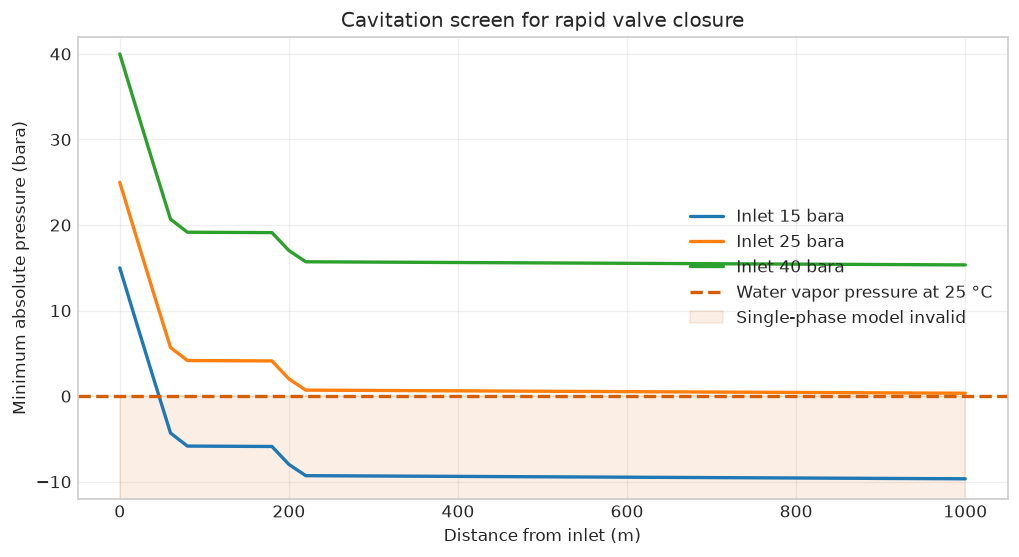

In [17]:
fig, ax = plt.subplots(figsize=(10.0, 5.0))

for screening_pressure_bara, profile in cavitation_profiles.items():
    ax.plot(
        positions_m,
        profile,
        linewidth=2.0,
        label=f"Inlet {screening_pressure_bara:.0f} bara",
    )

ax.axhline(
    WATER_VAPOR_PRESSURE_BARA,
    color=COLORS["red"],
    linestyle="--",
    linewidth=2.0,
    label="Water vapor pressure at 25 °C",
)
ax.fill_between(
    positions_m,
    -12.0,
    WATER_VAPOR_PRESSURE_BARA,
    color=COLORS["red"],
    alpha=0.10,
    label="Single-phase model invalid",
)
ax.set_ylim(-12.0, 42.0)
ax.set_xlabel("Distance from inlet (m)")
ax.set_ylabel("Minimum absolute pressure (bara)")
ax.set_title("Cavitation screen for rapid valve closure")
ax.legend(loc="center right")
ax.grid(alpha=0.3)
plt.show()

**Figure interpretation.** The 15 bara case crosses the vapor-pressure line and must be
escalated to a column-separation or discrete-vapor-cavity model. The 25 and 40 bara cases
retain positive margin for these assumptions.

## 9. Example 5 — inclined pipeline

`WaterHammerPipe` accepts one net outlet-minus-inlet elevation change. The original
arbitrary-profile call is therefore replaced by a transparent constant 100 m rise. The
initial pressure difference between flat and uphill cases should be close to the
hydrostatic contribution $\rho g \Delta z$.

In [18]:
flat_result = simulate_valve_closure(
    inlet_pressure_bara=55.0,
    closure_duration_s=0.50,
    total_time_s=4.0,
    elevation_change_m=0.0,
    snapshot_times_s=(),
)
uphill_result = simulate_valve_closure(
    inlet_pressure_bara=55.0,
    closure_duration_s=0.50,
    total_time_s=4.0,
    elevation_change_m=100.0,
    snapshot_times_s=(),
)

flat_outlet_initial_bara = flat_result["initial_pressure_bar"][-1]
uphill_outlet_initial_bara = uphill_result["initial_pressure_bar"][-1]
hydrostatic_difference_bar = (
    neqsim_density_kg_m3 * 9.80665 * 100.0 / 1.0e5
)
simulated_difference_bar = (
    flat_outlet_initial_bara - uphill_outlet_initial_bara
)

elevation_report = pd.DataFrame(
    {
        "quantity": [
            "Flat initial outlet pressure",
            "Uphill initial outlet pressure",
            "Simulated elevation contribution",
            "Hydrostatic estimate",
        ],
        "value": [
            flat_outlet_initial_bara,
            uphill_outlet_initial_bara,
            simulated_difference_bar,
            hydrostatic_difference_bar,
        ],
        "unit": ["bara", "bara", "bar", "bar"],
    }
)
display(elevation_report.round(4))

,quantity,value,unit
0,Flat initial outlet pressure,54.0567,bara
1,Uphill initial outlet pressure,44.2193,bara
2,Simulated elevation contribution,9.8374,bar
3,Hydrostatic estimate,9.8312,bar


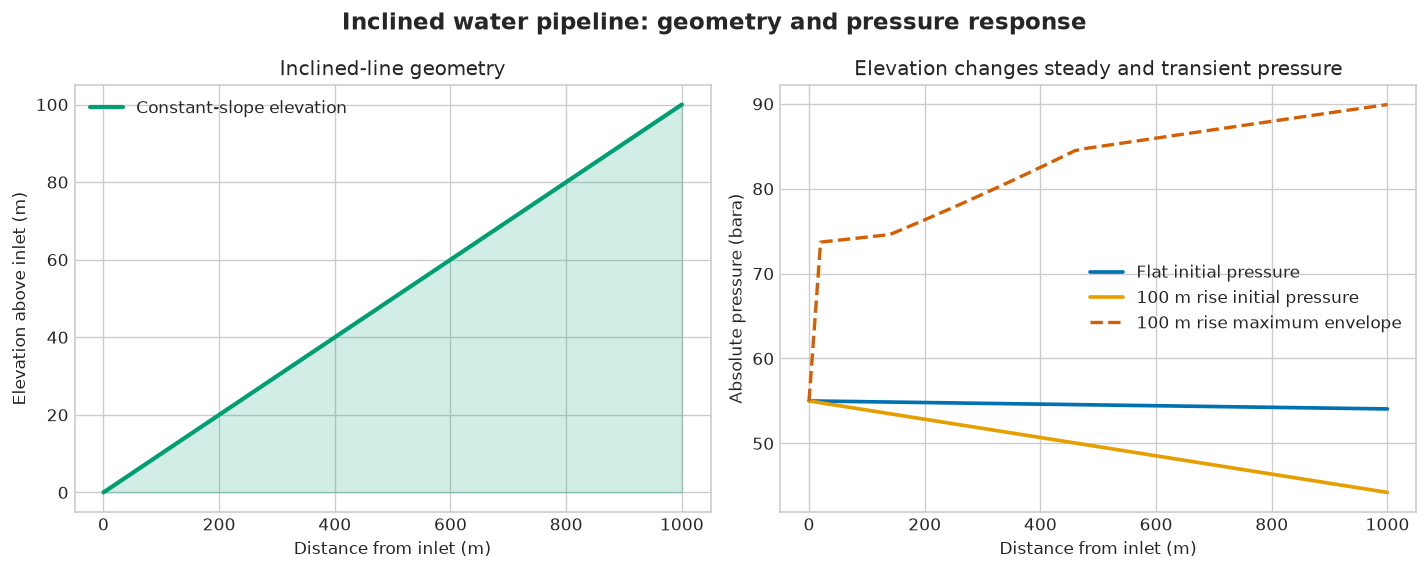

In [19]:
elevation_m = 100.0 * positions_m / PIPE_LENGTH_M
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

axes[0].plot(
    positions_m,
    elevation_m,
    color=COLORS["green"],
    linewidth=2.5,
    label="Constant-slope elevation",
)
axes[0].fill_between(
    positions_m,
    0.0,
    elevation_m,
    color=COLORS["green"],
    alpha=0.18,
)
axes[0].set_xlabel("Distance from inlet (m)")
axes[0].set_ylabel("Elevation above inlet (m)")
axes[0].set_title("Inclined-line geometry")
axes[0].legend(loc="upper left")

axes[1].plot(
    positions_m,
    flat_result["initial_pressure_bar"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="Flat initial pressure",
)
axes[1].plot(
    positions_m,
    uphill_result["initial_pressure_bar"],
    color=COLORS["orange"],
    linewidth=2.2,
    label="100 m rise initial pressure",
)
axes[1].plot(
    positions_m,
    uphill_result["max_envelope_bar"],
    color=COLORS["red"],
    linestyle="--",
    linewidth=2.0,
    label="100 m rise maximum envelope",
)
axes[1].set_xlabel("Distance from inlet (m)")
axes[1].set_ylabel("Absolute pressure (bara)")
axes[1].set_title("Elevation changes steady and transient pressure")
axes[1].legend(loc="best")

fig.suptitle(
    "Inclined water pipeline: geometry and pressure response",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Figure interpretation.** The uphill line begins with lower downstream pressure because
part of the inlet head supports elevation. The transient envelope must still be checked
independently; static head alone does not determine the surge maximum.

## 10. Example 6 — pipe material and wave speed

Lower wall stiffness increases compliance and reduces wave speed. The comparison holds
diameter and thickness fixed to isolate the modulus effect; real material substitutions
also change allowable stress, wall thickness, restraint, fatigue, and temperature limits.

In [20]:
material_moduli_gpa = {
    "Carbon steel": 210.0,
    "Ductile iron": 170.0,
    "GRP": 25.0,
    "HDPE": 1.0,
}
material_results = []

for material_name, modulus_gpa in material_moduli_gpa.items():
    wave_speed_m_s = korteweg_wave_speed(modulus_gpa * 1.0e9)
    critical_time_s = 2.0 * PIPE_LENGTH_M / wave_speed_m_s
    surge_bar = (
        neqsim_density_kg_m3
        * wave_speed_m_s
        * rapid_initial_velocity_m_s
        / 1.0e5
    )
    material_results.append(
        {
            "material": material_name,
            "elastic_modulus_GPa": modulus_gpa,
            "wave_speed_m_s": wave_speed_m_s,
            "critical_closure_time_s": critical_time_s,
            "rapid_surge_bar": surge_bar,
        }
    )

material_table = pd.DataFrame(material_results)
display(material_table.round(3))

,material,elastic_modulus_GPa,wave_speed_m_s,critical_closure_time_s,rapid_surge_bar
0,Carbon steel,210.0,1293.438,1.546,25.618
1,Ductile iron,170.0,1258.636,1.589,24.928
2,GRP,25.0,778.097,2.570,15.411
3,HDPE,1.0,181.473,11.021,3.594


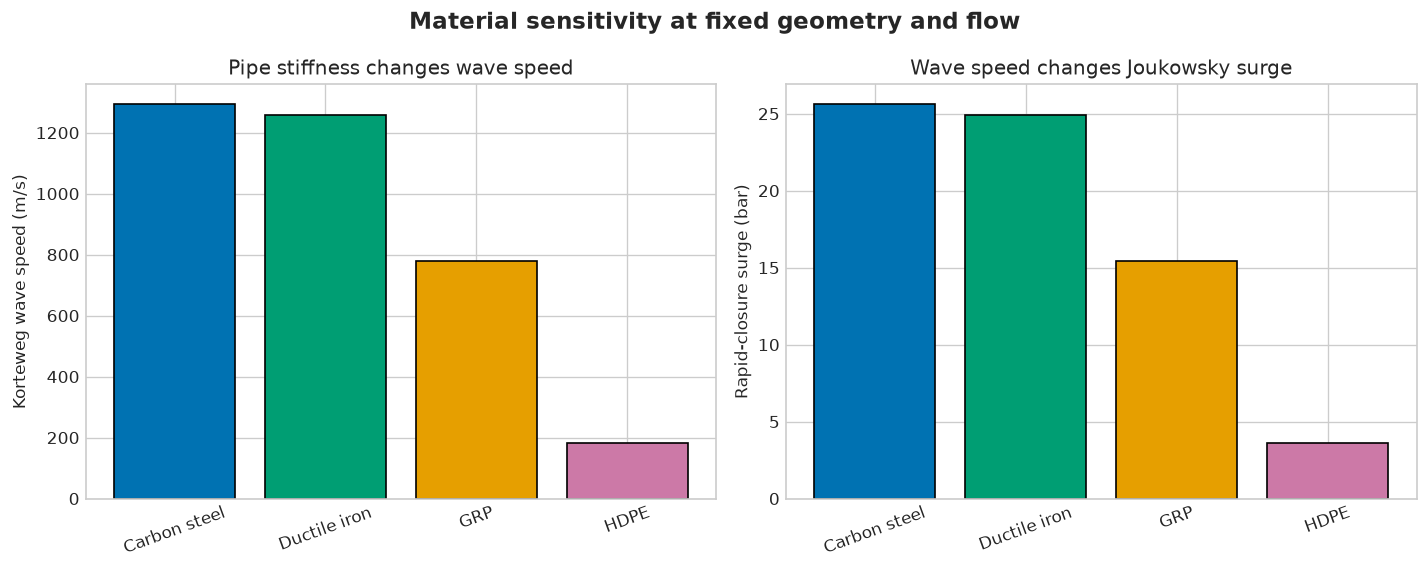

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
material_colors = [
    COLORS["blue"],
    COLORS["green"],
    COLORS["orange"],
    COLORS["purple"],
]

axes[0].bar(
    material_table["material"],
    material_table["wave_speed_m_s"],
    color=material_colors,
    edgecolor="black",
)
axes[0].set_ylabel("Korteweg wave speed (m/s)")
axes[0].set_title("Pipe stiffness changes wave speed")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    material_table["material"],
    material_table["rapid_surge_bar"],
    color=material_colors,
    edgecolor="black",
)
axes[1].set_ylabel("Rapid-closure surge (bar)")
axes[1].set_title("Wave speed changes Joukowsky surge")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle(
    "Material sensitivity at fixed geometry and flow",
    fontsize=14,
    weight="bold",
)
fig.tight_layout()
plt.show()

**Figure interpretation.** The more compliant HDPE wall strongly lowers acoustic speed
and the rapid-closure surge, while increasing the critical closure time. This comparison
is a wave-physics sensitivity, not a complete material-selection study.

## 11. Final application — select an ESD valve closure time

The practical workflow combines configuration, execution, result retrieval, validity
checks, and scenario selection. Assume a screening maximum allowable working pressure
(MAWP) of 62 bara and a minimum transient operating pressure of 2 bara. We choose the
shortest tested closure that satisfies both limits, then retain slower options as design
margin.

In [22]:
MAWP_BARA = 62.0
MINIMUM_OPERATING_PRESSURE_BARA = 2.0

design_table = closure_table.copy()
design_table["overpressure_margin_bar"] = (
    MAWP_BARA - design_table["maximum_pressure_bara"]
)
design_table["low_pressure_margin_bar"] = (
    design_table["minimum_pressure_bara"]
    - MINIMUM_OPERATING_PRESSURE_BARA
)
design_table["acceptable"] = (
    (design_table["overpressure_margin_bar"] >= 0.0)
    & (design_table["low_pressure_margin_bar"] >= 0.0)
)

acceptable_designs = design_table.loc[
    design_table["acceptable"]
].sort_values("closure_time_s")
selected_design = acceptable_designs.iloc[0]

display(design_table.round(4))
print(
    "Selected minimum tested closure duration: "
    f"{selected_design['closure_time_s']:.2f} s"
)

Selected minimum tested closure duration: 1.60 s


,closure_time_s,closure_ratio,maximum_pressure_bara,minimum_pressure_bara,overpressure_margin_bar,low_pressure_margin_bar,acceptable
0,0.1,0.0647,65.4932,15.3407,-3.4932,13.3407,False
1,0.5,0.3234,65.4326,15.3230,-3.4326,13.3230,False
2,1.0,0.6467,65.3569,15.2982,-3.3569,13.2982,False
3,1.6,1.0348,61.5487,22.4822,0.4513,20.4822,True
4,2.4,1.5521,55.3491,34.4643,6.6509,32.4643,True
5,3.0,1.9402,52.8691,37.9595,9.1309,35.9595,True


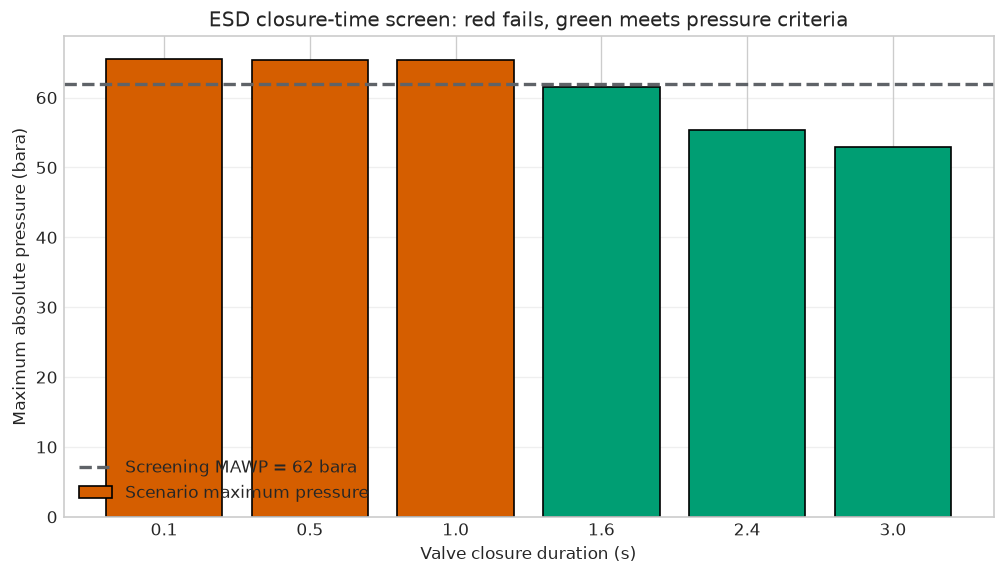

In [23]:
fig, ax = plt.subplots(figsize=(10.0, 5.2))
bar_colors = np.where(
    design_table["acceptable"],
    COLORS["green"],
    COLORS["red"],
)
ax.bar(
    design_table["closure_time_s"].astype(str),
    design_table["maximum_pressure_bara"],
    color=bar_colors,
    edgecolor="black",
    label="Scenario maximum pressure",
)
ax.axhline(
    MAWP_BARA,
    color=COLORS["grey"],
    linestyle="--",
    linewidth=2.0,
    label=f"Screening MAWP = {MAWP_BARA:.0f} bara",
)
ax.set_xlabel("Valve closure duration (s)")
ax.set_ylabel("Maximum absolute pressure (bara)")
ax.set_title(
    "ESD closure-time screen: red fails, green meets pressure criteria"
)
ax.legend(loc="lower left")
ax.grid(axis="y", alpha=0.3)
plt.show()

**Figure interpretation.** A 1.60 s closure is the shortest tested option below the
screening MAWP while maintaining ample low-pressure margin. A real design would refine
the valve characteristic, include actuator tolerances and failure modes, and check surge
devices, supports, cyclic fatigue, and credible operating states.

## 12. Verification and engineering checks

The assertions check units, finite values, fluid plausibility, Courant stability, the
rapid-closure limit, expected sensitivity directions, vapor-pressure classification,
hydrostatic head, material trends, and final design criteria. They are focused checks,
not an external benchmark certification.

In [24]:
checks = {
    "NeqSim version recorded": bool(NEQSIM_VERSION),
    "Python version recorded": bool(PYTHON_VERSION),
    "Java version recorded": bool(JAVA_VERSION),
    "Liquid density plausible": (
        950.0 < neqsim_density_kg_m3 < 1050.0
    ),
    "Viscosity positive": neqsim_viscosity_pa_s > 0.0,
    "Engineering wave speed plausible": (
        1000.0 < STEEL_WAVE_SPEED_M_S < 1500.0
    ),
    "Courant number at limit": abs(courant_number - 1.0) < 1.0e-10,
    "Initial velocity positive": rapid_initial_velocity_m_s > 0.0,
    "Rapid maximum finite": np.isfinite(
        rapid_result["max_envelope_bar"]
    ).all(),
    "Rapid minimum finite": np.isfinite(
        rapid_result["min_envelope_bar"]
    ).all(),
    "Joukowsky agreement within 2 percent": (
        abs(
            rapid_result["max_pressure_bar"]
            - joukowsky_peak_bara
        )
        / joukowsky_peak_bara
        < 0.02
    ),
    "Base case above vapor pressure": (
        rapid_result["min_pressure_bar"]
        > WATER_VAPOR_PRESSURE_BARA
    ),
    "Rapid closure plateau reproduced": (
        abs(
            closure_table.iloc[0]["maximum_pressure_bara"]
            - closure_table.iloc[1]["maximum_pressure_bara"]
        )
        < 0.2
    ),
    "Slow closure reduces maximum pressure": (
        closure_table.iloc[-1]["maximum_pressure_bara"]
        < closure_table.iloc[0]["maximum_pressure_bara"]
    ),
    "Slow closure raises minimum pressure": (
        closure_table.iloc[-1]["minimum_pressure_bara"]
        > closure_table.iloc[0]["minimum_pressure_bara"]
    ),
    "Low-inlet case flagged invalid": (
        not bool(cavitation_table.iloc[0]["single_phase_valid"])
    ),
    "Base inlet case remains single phase": bool(
        cavitation_table.iloc[-1]["single_phase_valid"]
    ),
    "Hydrostatic elevation agreement": (
        abs(
            simulated_difference_bar
            - hydrostatic_difference_bar
        )
        < 0.05
    ),
    "Steel wave speed exceeds HDPE": (
        material_table.iloc[0]["wave_speed_m_s"]
        > material_table.iloc[-1]["wave_speed_m_s"]
    ),
    "Steel surge exceeds HDPE": (
        material_table.iloc[0]["rapid_surge_bar"]
        > material_table.iloc[-1]["rapid_surge_bar"]
    ),
    "At least one acceptable design": not acceptable_designs.empty,
    "Selected design meets MAWP": (
        selected_design["maximum_pressure_bara"] <= MAWP_BARA
    ),
    "Selected design meets minimum pressure": (
        selected_design["minimum_pressure_bara"]
        >= MINIMUM_OPERATING_PRESSURE_BARA
    ),
    "Five spatial snapshots retained": (
        len(rapid_result["snapshot_pressure_bar"]) == 5
    ),
}

failed_checks = [
    check_name
    for check_name, passed in checks.items()
    if not passed
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(checks)} engineering checks passed.")

All 24 engineering checks passed.


## 13. Troubleshooting

- **No wave appears:** verify `setDownstreamBoundary("VALVE")`, call `run()` once, and
  change valve opening before each `runTransient(dt)`.
- **Unstable or jagged response:** use `getMaxStableTimeStep()` and do not exceed it.
- **Repeated sensitivity cases fail with duplicate equipment names:** construct fresh Java
  `Stream` and `WaterHammerPipe` objects rather than accumulating helpers in one global
  `ProcessSystem`.
- **Minimum pressure falls below vapor pressure:** stop interpreting the single-phase
  result quantitatively and use a cavitation-capable transient method.
- **Surge disagrees with Joukowsky:** check pressure units, velocity change, density, wave
  speed, valve schedule, and whether closure is actually rapid.

## 14. Applicability and limitations

This workflow is suitable for education, early option screening, API prototyping, and
transparent checks of single-phase liquid transients in a simple line. It is not a
substitute for design-grade surge analysis when vapor cavities, entrained gas, branched
networks, pump trips, check-valve dynamics, relief devices, accumulators, viscoelastic
pipe, frequency-dependent friction, structural interaction, or detailed terrain govern.

The inclined example uses one net elevation change because that is the current released
API. The cavitation example detects loss of model validity; it does not simulate cavity
formation or collapse.

## 15. Summary

- NeqSim supplies the liquid state, stream, steady initialization, MOC transient solver,
  boundary conditions, histories, profiles, and envelopes.
- The 0.10 s closure reproduces the Joukowsky rapid-closure limit.
- Closures longer than the wave round-trip time reduce pressure extremes.
- Vapor-pressure comparison is a validity screen, not a cavitation model.
- Elevation adds the expected hydrostatic contribution.
- Pipe-wall stiffness changes wave speed, critical time, and surge magnitude.
- For this screening basis, the shortest tested acceptable ESD closure is selected from
  explicit maximum- and minimum-pressure criteria.

## 16. Further exercises

1. Repeat the analysis for a longer line and explain how critical closure time changes.
2. Vary node count and confirm that the Courant-limited result is grid-consistent.
3. Compare two wall thicknesses while keeping material modulus fixed.
4. Add an initial-flow sensitivity and normalize surge by the Joukowsky estimate.
5. Replace the linear valve schedule with an equal-percentage or measured actuator curve.
6. Define a separate low-pressure operating case and determine where a cavitation-capable
   model becomes mandatory.

## 17. References

- NeqSim source and API: [`WaterHammerPipe`](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/WaterHammerPipe.java)
- NeqSim Python package: [PyPI `neqsim`](https://pypi.org/project/neqsim/)
- Wylie, E. B., Streeter, V. L., and Suo, L. (1993), *Fluid Transients in Systems*.
- Chaudhry, M. H. (2014), *Applied Hydraulic Transients*, 3rd edition.
- Joukowsky, N. (1900), classical relation for rapid velocity-change pressure surge.